In [1]:
"""
GPP regional maps
@L. Leverne/F. Maignan
"""

#import
import pandas as pd
from netCDF4 import Dataset
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.cm as cm
from matplotlib import ticker 
import numpy as np
import glob
import math
import xarray as xr
import netCDF4

import seaborn as sns
from mpl_toolkits.basemap import Basemap
from statsmodels.formula.api import ols
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FormatStrFormatter

In [2]:
#https://stackoverflow.com/questions/18195758/set-matplotlib-colorbar-size-to-match-graph
def add_colorbar(im, aspect=20, pad_fraction=0.5, **kwargs):
    """Add a vertical color bar to an image plot."""
    divider = axes_grid1.make_axes_locatable(im.axes)
    width = axes_grid1.axes_size.AxesY(im.axes, aspect=1./aspect)
    pad = axes_grid1.axes_size.Fraction(pad_fraction, width)
    current_ax = plt.gca()
    cax = divider.append_axes("right", size=width, pad=pad)
    plt.sca(current_ax)
    return im.axes.figure.colorbar(im, cax=cax, **kwargs)

In [3]:
def rmse(observation, prediction):
    RMSE =math.sqrt(np.nanmean((np.array(observation)-np.array(prediction))**2))
    RMSE= round(RMSE,3)
    return RMSE

In [4]:
def r2(x, y):
    return stats.pearsonr(x, y)[0] ** 2

In [5]:
def bias(prediction,observation):
    bias = (prediction - observation).mean()
    return bias

In [6]:
def plot_map(gpp,vmin_GPP,vmax_GPP,palette):
    precision=2
    nbins=round((vmax_GPP-vmin_GPP)*precision)
    count=nbins
    min_val, max_val = 0.0,1.0
    n = 100
    orig_cmap = plt.get_cmap(palette)
    colors = orig_cmap(np.linspace(min_val, max_val, n))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("mycmap", colors, count)
    
    fig, ax = plt.subplots(figsize=(7,7))
    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    cs = m.pcolormesh(xi,yi,np.squeeze(gpp),cmap=cmap,vmin=vmin_GPP,vmax=vmax_GPP)
    # Add Grid Lines
    m.drawparallels(np.arange(-90., 91., 10.), labels=[1,0,0,0], fontsize=12)
    m.drawmeridians(np.arange(-180., 181., 30.), labels=[0,0,0,1], fontsize=12)
    # Add Coastlines, States, and Country Boundaries
    m.drawcoastlines()

    # Add Colorbar
    tick_locator = ticker.MaxNLocator(nbins=math.ceil(nbins/2))
    cbar = m.colorbar(cs, location='bottom', pad="15%",ticks=tick_locator)
    cbar.ax.yaxis.set_ticks([])
    cbar.ax.yaxis.set_ticklabels([])
    cbar.update_ticks()
    cbar.ax.set_title('GPP annual mean ($\mathrm{gC.m^{-2}.d^{-1}}$)',fontsize=fontsize_label)    
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    cbar.ax.tick_params(labelsize=12)

In [7]:
def plot_map_diff(gpp,vmin_GPP,vmax_GPP,palette):
    precision=2
    nbins=round((vmax_GPP-vmin_GPP)*precision)
    count=nbins
    min_val, max_val = 0.0,1.0
    n = 100
    orig_cmap = plt.get_cmap(palette)
    colors = orig_cmap(np.linspace(min_val, max_val, n))
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("mycmap", colors, count)

    # Step 1: Define discrete colors (example uses 5 bins: 2 below, grey, 2 above)
    colors = [
        (0, 0, 0.5),       # Very dark blue (lowest)
        (0, 0, 1),         # Dark blue
        (0.4, 0.4, 1),     # Light blue
        (0.7, 0.7, 0.7),   # Grey (middle)
        (1, 0.6, 0.6),     # Light red
        (1, 0.2, 0.2),     # Medium red
        (0.6, 0, 0)        # Dark red (highest)
    ]

    nbins=len(colors)
    # Step 2: Create the colormap
    cmap_diff = ListedColormap(colors, name='red-grey-blue')

    # Step 3: Define bin edges to match your range
    # For 5 colors => 6 boundaries:
    bounds = np.linspace(vmin_GPP, vmax_GPP, len(colors) + 1)
    norm = BoundaryNorm(bounds, cmap_diff.N)

    fig, ax = plt.subplots(figsize=(7,7))
    fig.tight_layout()
    plt.subplots_adjust(top=0.95)
    cs = m.pcolormesh(xi,yi,np.squeeze(gpp),cmap=cmap_diff,norm=norm)
    # Add Grid Lines
    m.drawparallels(np.arange(-90., 91., 10.), labels=[1,0,0,0], fontsize=12)
    m.drawmeridians(np.arange(-180., 181., 30.), labels=[0,0,0,1], fontsize=12)
    # Add Coastlines, States, and Country Boundaries
    m.drawcoastlines()

    # Add Colorbar
    tick_locator = bounds
    cbar = m.colorbar(cs, location='bottom', pad="15%",ticks=tick_locator)
    cbar.ax.yaxis.set_ticks([])
    cbar.ax.yaxis.set_ticklabels([])
    cbar.update_ticks()
    cbar.ax.set_title('GPP annual mean ($\mathrm{gC.m^{-2}.d^{-1}}$)',fontsize=fontsize_label)    
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    cbar.ax.tick_params(labelsize=12)

In [8]:
fontsize_title=16
fontsize_label=14
fontsize_legend=12

seuil=0.5

obs = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_obs_fluxsat_201222.nc')
obs2 = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_obs_fluxcom_201222.nc')
bacour = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_bacour_201222.nc')
raczka = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_raczka_201222.nc')
optgpp = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_optgpp_200122.nc')
optsif = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_optsif_200122.nc')
bacouropt = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_bacouropt_201222.nc')

obs = obs.rename({'time':'time_counter'})
obs2 = obs2.rename({'time':'time_counter'})

date_fin="2020-12-31"
obs = obs.sel(time_counter=slice("2001-01-01", date_fin))
obs2 = obs2.sel(time_counter=slice("2001-01-01", date_fin))
bacour = bacour.sel(time_counter=slice("2001-01-01", date_fin))
raczka = raczka.sel(time_counter=slice("2001-01-01", date_fin))
optsif = optsif.sel(time_counter=slice("2001-01-01", date_fin))
optgpp = optgpp.sel(time_counter=slice("2001-01-01", date_fin))
bacouropt = bacouropt.sel(time_counter=slice("2001-01-01", date_fin))

#Masking to keep common grid cells
obs  = obs.assign_coords(time_counter=bacour.time_counter)
obs2 = obs2.assign_coords(time_counter=bacour.time_counter)
mask = np.isnan(obs.GPP) | np.isnan(raczka.GPP) 
obs['GPP'] = xr.where(mask,np.nan,obs.GPP)
obs2['GPP'] = xr.where(mask,np.nan,obs2.GPP)
bacour['GPP'] = xr.where(mask,np.nan,bacour.GPP)
raczka['GPP'] = xr.where(mask,np.nan,raczka.GPP)
optsif['GPP'] = xr.where(mask,np.nan,optsif.GPP)
optgpp['GPP'] = xr.where(mask,np.nan,optgpp.GPP)

In [9]:
if True:
    #Plot
    obs  = obs.mean("time_counter")
    obs2  = obs2.mean("time_counter")
    bacour  = bacour.mean("time_counter")
    raczka  = raczka.mean("time_counter")
    optgpp  = optgpp.mean("time_counter")
    optsif  = optsif.mean("time_counter")
    bacouropt  = bacouropt.mean("time_counter")
    
    simu = raczka.variables['GPP'][:]
    lons = raczka.variables['lon'][:]
    lats = raczka.variables['lat'][:]
    
    obs = obs2.GPP
    diff=simu - obs
    
    # Get some parameters for the Stereographic Projection
    lon_0 = lons.mean()
    lat_0 = lats.mean()
                
    m = Basemap(projection='npstere',boundinglat=45,lon_0=0,resolution='l')
        
    # Because our lon and lat variables are 1D,
    # use meshgrid to create 2D arrays
    # Not necessary if coordinates are already in 2D arrays.
    lon, lat = np.meshgrid(lons, lats)
    xi, yi = m(lon, lat)

/tmp/ipykernel_21597/3179982548.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(xi,yi,np.squeeze(gpp),cmap=cmap,vmin=vmin_GPP,vmax=vmax_GPP)


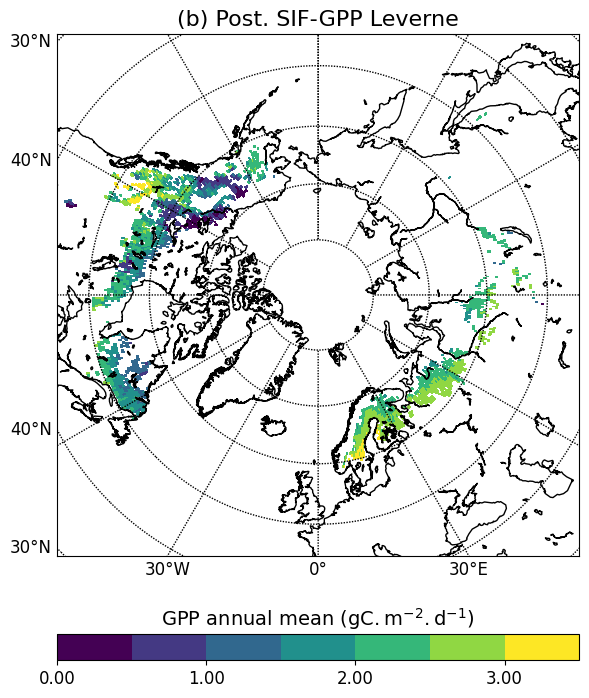

In [10]:
if True:
    vmin_GPP=0
    vmax_GPP=3.5
    palette='viridis'    

    #Simulation
    plot_map(simu,vmin_GPP,vmax_GPP,palette)
    plt.title('(b) Post. SIF-GPP Leverne',fontsize=fontsize_title)
    plt.show(block=False)
    #plt.savefig('./PNG/Figure4b.png')

/tmp/ipykernel_21597/3179982548.py:14: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(xi,yi,np.squeeze(gpp),cmap=cmap,vmin=vmin_GPP,vmax=vmax_GPP)


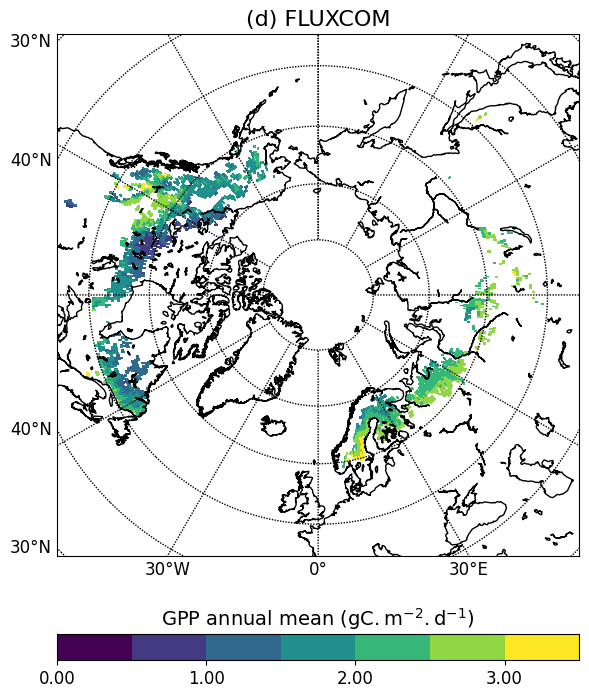

In [11]:
if True:
    vmin_GPP=0
    vmax_GPP=3.5
    palette='viridis'  

    #Obs
    plot_map(obs,vmin_GPP,vmax_GPP,palette)
    plt.title('(d) FLUXCOM',fontsize=fontsize_title)
    plt.show(block=False)
    #plt.savefig('./PNG/Figure4d.png')

/tmp/ipykernel_21597/4203740934.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = m.pcolormesh(xi,yi,np.squeeze(gpp),cmap=cmap_diff,norm=norm)


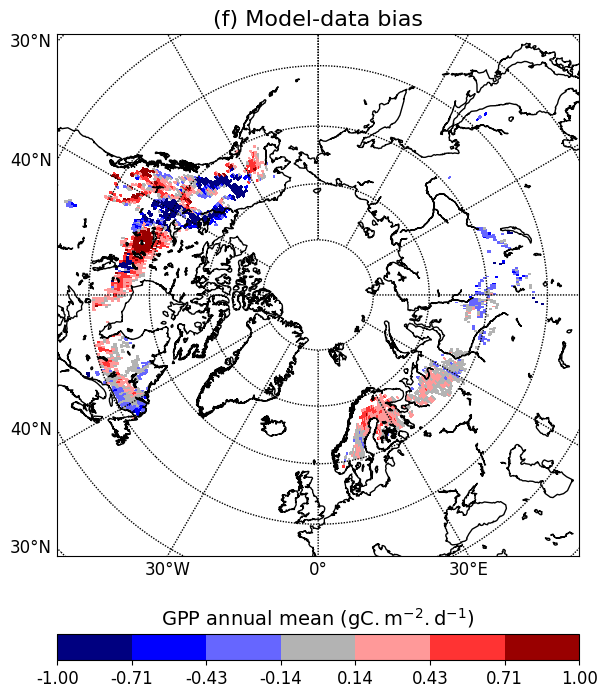

In [12]:
if True:
    #Difference
    vmin_GPP=-1.
    vmax_GPP=1.
    palette='seismic'

    # Add Title
    plot_map_diff(diff,vmin_GPP,vmax_GPP,palette)
    plt.title('(f) Model-data bias',fontsize=fontsize_title)
    plt.show(block=False)
    #plt.savefig('./PNG/Figure4f.png')